# 05 · Merge & Calendar Enrichment

**Inputs :**
- `data/processed/panel_daily.parquet`   (cycling, 149 sites × 731 days)
- `data/processed/weather_daily.parquet` (weather, 149 sites × 731 days)

**Output :** `data/processed/analysis_panel.parquet`

Steps:
0. Imports & load data
1. Merge cycling + weather
2. Belgian public holidays
3. Flemish school holidays
4. KU Leuven academic calendar
5. Combined calendar flags
6. Lagged weather variables
7. Quality check & date filter
8. Save final analysis panel
9. Calendar overview plot
10. KU Leuven period plot
11. Final summary

## 0. Imports & Load Data

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "holidays"])

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import holidays

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"

cycling = pd.read_parquet(PROCESSED / "panel_daily.parquet")
weather = pd.read_parquet(PROCESSED / "weather_daily.parquet")

# Guard against date32 / object dtype from parquet readers
cycling["date"] = pd.to_datetime(cycling["date"])
weather["date"] = pd.to_datetime(weather["date"])

print(f"cycling : {cycling.shape}")
print(f"weather : {weather.shape}")
print(f"cycling date range : {cycling['date'].min().date()} -> {cycling['date'].max().date()}")
print(f"weather date range : {weather['date'].min().date()} -> {weather['date'].max().date()}")

cycling : (108919, 19)
weather : (109068, 19)
cycling date range : 2024-01-01 -> 2025-12-31
weather date range : 2023-12-31 -> 2025-12-31


## 1. Merge Cycling + Weather

In [2]:
n_before = len(cycling)

merged = cycling.merge(
    weather,
    on=["site ID", "date"],
    how="left",
    validate="1:1",
)

n_nan_temp = merged["temp_avg"].isna().sum()
n_dup      = merged.duplicated(["site ID", "date"]).sum()

print(f"cycling rows        : {n_before:,}")
print(f"merged rows         : {len(merged):,}  (expected: {n_before:,})")
print(f"NaN in temp_avg     : {n_nan_temp:,}  ({n_nan_temp / len(merged) * 100:.1f}%)")
print(f"Duplicate (site,date): {n_dup}  (should be 0)")

cycling rows        : 108,919
merged rows         : 108,919  (expected: 108,919)
NaN in temp_avg     : 0  (0.0%)
Duplicate (site,date): 0  (should be 0)


## 2. Add Belgian Public Holidays

In [3]:
be_holidays = holidays.Belgium(years=[2024, 2025])

holiday_dates = (
    pd.DataFrame([
        {"date": pd.Timestamp(d), "public_holiday_name": name}
        for d, name in be_holidays.items()
    ])
    .sort_values("date")
    .reset_index(drop=True)
)

n_before = len(merged)
merged = merged.merge(holiday_dates, on="date", how="left")
merged["is_public_holiday"] = merged["public_holiday_name"].notna()
assert len(merged) == n_before, "Public holiday merge duplicated rows!"

print(f"Belgian public holidays 2024-2025 ({len(holiday_dates)} total):")
for _, row in holiday_dates.iterrows():
    print(f"  {str(row['date'].date()):<12}  {row['public_holiday_name']}")

Belgian public holidays 2024-2025 (24 total):
  2024-01-01    Nieuwjaar
  2024-03-31    Pasen
  2024-04-01    Paasmaandag
  2024-05-01    Dag van de Arbeid
  2024-05-09    O. L. H. Hemelvaart
  2024-05-19    Pinksteren
  2024-05-20    Pinkstermaandag
  2024-07-21    Nationale feestdag
  2024-08-15    O. L. V. Hemelvaart
  2024-11-01    Allerheiligen
  2024-11-11    Wapenstilstand
  2024-12-25    Kerstmis
  2025-01-01    Nieuwjaar
  2025-04-20    Pasen
  2025-04-21    Paasmaandag
  2025-05-01    Dag van de Arbeid
  2025-05-29    O. L. H. Hemelvaart
  2025-06-08    Pinksteren
  2025-06-09    Pinkstermaandag
  2025-07-21    Nationale feestdag
  2025-08-15    O. L. V. Hemelvaart
  2025-11-01    Allerheiligen
  2025-11-11    Wapenstilstand
  2025-12-25    Kerstmis


## 3. Add Flemish School Holidays

Official dates from [onderwijs.vlaanderen.be](https://onderwijs.vlaanderen.be/nl/schoolvakanties).

In [4]:
school_holidays = [
    # School year 2023-2024 (dates within our window)
    ("2024-01-01", "2024-01-07",  "christmas_2023"),
    ("2024-02-12", "2024-02-18",  "spring_2024"),
    ("2024-04-01", "2024-04-14",  "easter_2024"),
    ("2024-07-01", "2024-08-31",  "summer_2024"),
    ("2024-10-28", "2024-11-03",  "autumn_2024"),
    # School year 2024-2025
    ("2024-12-23", "2025-01-05",  "christmas_2024"),
    ("2025-03-03", "2025-03-09",  "spring_2025"),
    ("2025-04-07", "2025-04-21",  "easter_2025"),
    ("2025-07-01", "2025-08-31",  "summer_2025"),
    ("2025-10-27", "2025-11-02",  "autumn_2025"),
    ("2025-12-22", "2025-12-31",  "christmas_2025"),
]

school_rows = []
for start, end, name in school_holidays:
    for d in pd.date_range(start, end, freq="D"):
        school_rows.append({"date": d, "school_holiday_name": name})

school_df = pd.DataFrame(school_rows)

n_before = len(merged)
merged = merged.merge(school_df, on="date", how="left")
merged["is_school_holiday"] = merged["school_holiday_name"].notna()
assert len(merged) == n_before, "School holiday merge duplicated rows!"

print("School holiday days per period:")
counts = school_df.groupby("school_holiday_name").size().sort_index()
for name, n in counts.items():
    print(f"  {name:<22} : {n:>3} days")
print(f"  {'TOTAL':<22} : {len(school_df):>3} calendar days")

School holiday days per period:
  autumn_2024            :   7 days
  autumn_2025            :   7 days
  christmas_2023         :   7 days
  christmas_2024         :  14 days
  christmas_2025         :  10 days
  easter_2024            :  14 days
  easter_2025            :  15 days
  spring_2024            :   7 days
  spring_2025            :   7 days
  summer_2024            :  62 days
  summer_2025            :  62 days
  TOTAL                  : 212 calendar days


## 4. Add KU Leuven Academic Calendar

Official dates from [kuleuven.be](https://www.kuleuven.be/onderwijs/academische-kalender).
Note: 2025-02-01 appears in both the `exam` and `recess` windows — the overlap is resolved by
keeping `exam` (first occurrence). Four calendar days have no period entry due to gaps in the
published schedule: 2024-06-30, 2024-09-08, 2025-06-09, 2025-06-29.

In [5]:
ku_leuven_periods = [
    # Academic year 2023-2024 (2024 portion)
    ("2024-01-01", "2024-01-07",  "recess"),
    ("2024-01-08", "2024-01-14",  "exam_prep"),
    ("2024-01-15", "2024-02-03",  "exam"),
    ("2024-02-04", "2024-02-11",  "recess"),
    ("2024-02-12", "2024-03-29",  "teaching"),
    ("2024-03-30", "2024-04-14",  "recess"),
    ("2024-04-15", "2024-05-24",  "teaching"),
    ("2024-05-25", "2024-06-09",  "exam_prep"),
    ("2024-06-10", "2024-06-29",  "exam"),
    ("2024-07-01", "2024-08-18",  "recess"),
    ("2024-08-19", "2024-09-07",  "exam"),
    ("2024-09-09", "2024-09-22",  "recess"),
    # Academic year 2024-2025
    ("2024-09-23", "2024-12-20",  "teaching"),
    ("2024-12-21", "2025-01-05",  "recess"),
    ("2025-01-06", "2025-01-12",  "exam_prep"),
    ("2025-01-13", "2025-02-01",  "exam"),
    ("2025-02-01", "2025-02-09",  "recess"),    # 2025-02-01 overlaps with exam above
    ("2025-02-10", "2025-04-04",  "teaching"),
    ("2025-04-05", "2025-04-21",  "recess"),
    ("2025-04-22", "2025-05-23",  "teaching"),
    ("2025-05-24", "2025-06-08",  "exam_prep"),
    ("2025-06-10", "2025-06-28",  "exam"),
    ("2025-06-30", "2025-08-17",  "recess"),
    ("2025-08-18", "2025-09-06",  "exam"),
    ("2025-09-07", "2025-12-31",  "teaching"),
]

ku_rows = []
for start, end, period in ku_leuven_periods:
    for d in pd.date_range(start, end, freq="D"):
        ku_rows.append({"date": d, "ku_leuven_period": period})

# Drop duplicate dates — e.g. 2025-02-01 appears in both exam and recess;
# keep first occurrence (exam takes precedence)
ku_df = (
    pd.DataFrame(ku_rows)
    .drop_duplicates("date", keep="first")
    .reset_index(drop=True)
)

n_before = len(merged)
merged = merged.merge(ku_df, on="date", how="left")
assert len(merged) == n_before, "KU Leuven merge duplicated rows!"

merged["ku_is_teaching"]  = merged["ku_leuven_period"] == "teaching"
merged["ku_is_exam"]      = merged["ku_leuven_period"] == "exam"
merged["ku_is_exam_prep"] = merged["ku_leuven_period"] == "exam_prep"
merged["ku_is_recess"]    = merged["ku_leuven_period"] == "recess"

print("KU Leuven period coverage (calendar days):")
print(ku_df["ku_leuven_period"].value_counts().sort_index())
n_total_days = len(pd.date_range("2024-01-01", "2025-12-31"))
n_gap = n_total_days - len(ku_df)
if n_gap > 0:
    gap_dates = pd.date_range("2024-01-01", "2025-12-31").difference(ku_df["date"])
    print(f"\nNote: {n_gap} date(s) have no KU Leuven period (schedule gaps):")
    print("  " + ", ".join(str(d.date()) for d in gap_dates))

KU Leuven period coverage (calendar days):
ku_leuven_period
exam         119
exam_prep     46
recess       184
teaching     378
Name: count, dtype: int64

Note: 4 date(s) have no KU Leuven period (schedule gaps):
  2024-06-30, 2024-09-08, 2025-06-09, 2025-06-29


## 5. Add Combined Calendar Flags

In [6]:
merged["is_any_holiday"] = (
    merged["is_public_holiday"] | merged["is_school_holiday"]
)

merged["is_regular_day"] = (
    ~merged["is_weekend"] &
    ~merged["is_public_holiday"] &
    ~merged["is_school_holiday"]
)

# Vectorised classify_day: public_holiday > weekend > school_holiday > regular_weekday
merged["day_type"] = np.select(
    condlist=[
        merged["is_public_holiday"],
        merged["is_weekend"],
        merged["is_school_holiday"],
    ],
    choicelist=["public_holiday", "weekend", "school_holiday"],
    default="regular_weekday",
)

print("day_type counts (site-days):")
print(merged["day_type"].value_counts())
print("\nday_type counts (unique calendar days):")
print(
    merged[["date", "day_type"]]
    .drop_duplicates("date")["day_type"]
    .value_counts()
)

day_type counts (site-days):
day_type
regular_weekday    53938
weekend            30098
school_holiday     21307
public_holiday      3576
Name: count, dtype: int64

day_type counts (unique calendar days):
day_type
regular_weekday    362
weekend            202
school_holiday     143
public_holiday      24
Name: count, dtype: int64


## 6. Add Lagged Weather Variables

Sort by `(site ID, date)` first so shifts stay within each station's time series.

In [7]:
merged = merged.sort_values(["site ID", "date"]).reset_index(drop=True)

for lag in [1, 2]:
    merged[f"temp_avg_lag{lag}"]     = merged.groupby("site ID")["temp_avg"].shift(lag)
    merged[f"precip_total_lag{lag}"] = merged.groupby("site ID")["precip_total"].shift(lag)
    merged[f"wind_avg_lag{lag}"]     = merged.groupby("site ID")["wind_avg"].shift(lag)

lag_cols = [c for c in merged.columns if "lag" in c]
print("Lag columns:", lag_cols)

first_site = merged["site ID"].iloc[0]
print(f"\nFirst 3 days of site ID {first_site} (lag1/lag2 NaN for day 1 and 2):")
display(
    merged[merged["site ID"] == first_site]
    [["site ID", "date",
      "temp_avg", "temp_avg_lag1", "temp_avg_lag2",
      "precip_total", "precip_total_lag1", "precip_total_lag2"]]
    .head(3)
)

Lag columns: ['temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'temp_avg_lag2', 'precip_total_lag2', 'wind_avg_lag2']

First 3 days of site ID 1 (lag1/lag2 NaN for day 1 and 2):


,site ID,date,temp_avg,temp_avg_lag1,temp_avg_lag2,precip_total,precip_total_lag1,precip_total_lag2
0,1,2024-01-01,7.302083,NaN,NaN,2.3,NaN,NaN
1,1,2024-01-02,10.522917,7.302083,NaN,21.6,2.3,NaN
2,1,2024-01-03,9.033334,10.522917,7.302083,3.7,21.6,2.3


## 7. Final Quality Check

In [8]:
# Date range filter
n_before = len(merged)
merged = merged[
    (merged["date"] >= "2024-01-01") &
    (merged["date"] <= "2025-12-31")
].reset_index(drop=True)
dropped = n_before - len(merged)
if dropped:
    print(f"Dropped {dropped:,} rows outside 2024-2025.")
else:
    print(f"All {len(merged):,} rows are within 2024-2025. OK")

print(f"Date range : {merged['date'].min().date()} -> {merged['date'].max().date()}")

print(f"\nAll columns ({len(merged.columns)}):")
for i, c in enumerate(merged.columns):
    print(f"  [{i:02d}] {c}")

print("\nDescriptive statistics:")
desc_cols = ["aantal", "temp_avg", "precip_total", "wind_avg",
             "humidity_avg", "sunshine_min", "peak_ratio"]
display(merged[desc_cols].describe(percentiles=[.25, .5, .75]).round(2))

# Weather coverage per site
no_wx = (
    merged.groupby("site ID")["temp_avg"]
    .apply(lambda s: s.notna().sum())
)
zero_wx = no_wx[no_wx == 0]
if len(zero_wx):
    print(f"\nWARNING: {len(zero_wx)} site(s) have zero weather coverage: {zero_wx.index.tolist()}")
else:
    print(f"\nAll {merged['site ID'].nunique()} sites have weather coverage. OK")

All 108,919 rows are within 2024-2025. OK
Date range : 2024-01-01 -> 2025-12-31

All columns (54):
  [00] site ID
  [01] date
  [02] aantal
  [03] morning_peak_count
  [04] evening_peak_count
  [05] peak_ratio
  [06] year
  [07] month
  [08] dayofweek
  [09] is_weekend
  [10] season
  [11] low_coverage
  [12] lon
  [13] lat
  [14] naam
  [15] gemeente
  [16] wegnr
  [17] district
  [18] install_date
  [19] temp_avg
  [20] temp_max
  [21] temp_min
  [22] precip_total
  [23] wind_avg
  [24] wind_max
  [25] humidity_avg
  [26] sunshine_min
  [27] rain_hours
  [28] precip_morning
  [29] wind_morning
  [30] precip_evening
  [31] wind_evening
  [32] is_rainy_day
  [33] is_cold_day
  [34] is_windy_day
  [35] is_bad_weather
  [36] public_holiday_name
  [37] is_public_holiday
  [38] school_holiday_name
  [39] is_school_holiday
  [40] ku_leuven_period
  [41] ku_is_teaching
  [42] ku_is_exam
  [43] ku_is_exam_prep
  [44] ku_is_recess
  [45] is_any_holiday
  [46] is_regular_day
  [47] day_type
  [

,aantal,temp_avg,precip_total,wind_avg,humidity_avg,sunshine_min,peak_ratio
count,100585.00,108919.00,108919.00,108919.00,108919.00,108919.00,99080.00
mean,509.67,11.74,2.32,12.94,78.24,453.11,0.27
std,711.37,6.16,4.12,5.71,10.48,288.30,0.11
min,0.00,-4.58,0.00,1.49,34.53,0.00,0.00
25%,149.00,7.50,0.00,8.64,72.02,207.39,0.19
50%,312.00,11.86,0.40,12.07,79.41,470.94,0.27
75%,572.00,16.39,3.00,16.31,86.31,699.46,0.34
max,8139.00,29.74,49.90,41.96,99.23,960.00,1.00



All 149 sites have weather coverage. OK


## 8. Save Final Analysis Dataset

In [9]:
out = PROCESSED / "analysis_panel.parquet"
merged.to_parquet(out, index=False)
size_mb = out.stat().st_size / 1_048_576

print(f"Saved : {out}")
print(f"Shape : {merged.shape}")
print(f"Size  : {size_mb:.1f} MB")
print("\nPreview (5 rows):")
display(
    merged[["site ID", "naam", "date", "aantal",
            "temp_avg", "precip_total",
            "day_type", "is_school_holiday",
            "ku_leuven_period", "peak_ratio"]]
    .head(5)
)

Saved : /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/analysis_panel.parquet
Shape : (108919, 54)
Size  : 4.8 MB

Preview (5 rows):


,site ID,naam,date,aantal,temp_avg,precip_total,day_type,is_school_holiday,ku_leuven_period,peak_ratio
0,1,Machelen,2024-01-01,107.0,7.302083,2.3,public_holiday,True,recess,0.093458
1,1,Machelen,2024-01-02,147.0,10.522917,21.6,school_holiday,True,recess,0.408163
2,1,Machelen,2024-01-03,166.0,9.033334,3.7,school_holiday,True,recess,0.361446
3,1,Machelen,2024-01-04,297.0,8.085417,3.4,school_holiday,True,recess,0.242424
4,1,Machelen,2024-01-05,180.0,7.395833,4.7,school_holiday,True,recess,0.377778


## 9. Summary Plot — fig08_calendar_overview.png

Left: stacked bar of day types by month.
Right: average daily cyclist count by day type (well-covered stations, with ±1 std error bars).

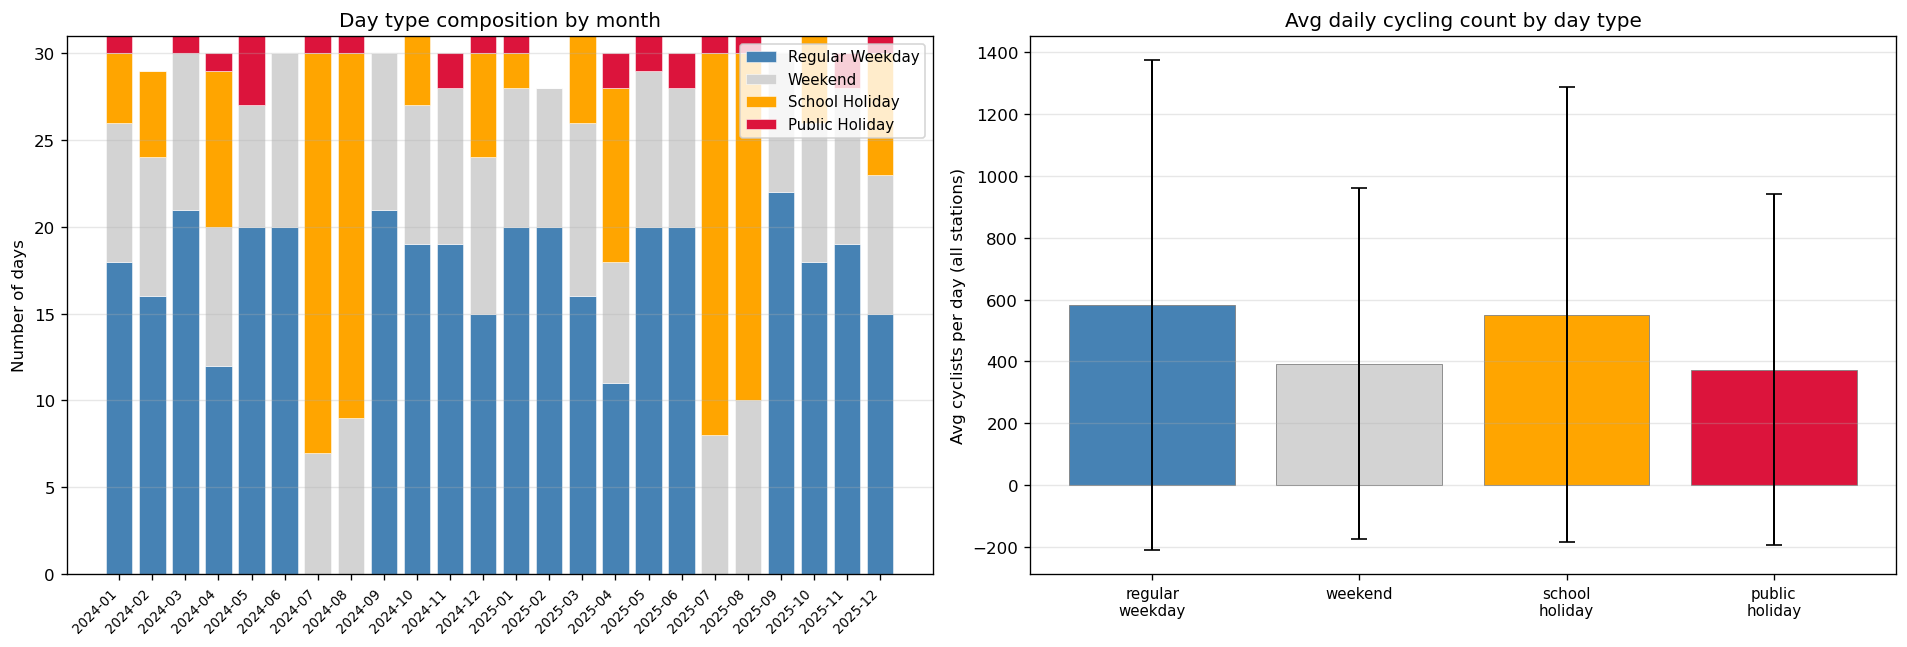

fig08_calendar_overview.png saved.


In [10]:
DAY_COLORS = {
    "regular_weekday": "steelblue",
    "weekend":         "lightgray",
    "school_holiday":  "orange",
    "public_holiday":  "crimson",
}
ORDER = ["regular_weekday", "weekend", "school_holiday", "public_holiday"]

# Deduplicate on date — each calendar day should count once regardless of #sites
dates_only = (
    merged[["date", "day_type"]]
    .drop_duplicates("date")
    .assign(ym=lambda df: df["date"].dt.to_period("M"))
)
pivot = (
    dates_only.groupby(["ym", "day_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER, fill_value=0)
)
x_pos    = list(range(len(pivot)))
x_labels = [str(p) for p in pivot.index]

# Right panel: avg daily count by day_type (well-covered stations only)
day_stats = (
    merged[~merged["low_coverage"]]
    .groupby("day_type")["aantal"]
    .agg(mean="mean", std="std")
    .reindex(ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: stacked bar by month
ax = axes[0]
bottoms = np.zeros(len(pivot))
for col in ORDER:
    vals = pivot[col].values.astype(float)
    ax.bar(x_pos, vals, bottom=bottoms,
           color=DAY_COLORS[col], label=col.replace("_", " ").title(),
           edgecolor="white", lw=0.3)
    bottoms += vals
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of days")
ax.set_title("Day type composition by month")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

# Right: avg cycling count with error bars
ax = axes[1]
means  = day_stats["mean"].values
stds   = day_stats["std"].values
colors = [DAY_COLORS[d] for d in ORDER]
ax.bar(range(len(ORDER)), means, yerr=stds, color=colors,
       capsize=5, edgecolor="grey", lw=0.5, error_kw={"elinewidth": 1.2})
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([d.replace("_", "\n") for d in ORDER], fontsize=9)
ax.set_ylabel("Avg cyclists per day (all stations)")
ax.set_title("Avg daily cycling count by day type")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGS / "fig08_calendar_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("fig08_calendar_overview.png saved.")

## 10. KU Leuven Period Plot — fig09_artoisplein_kuleuven.png

Daily cycling at Artoisplein with background shading by KU Leuven academic period.

Plotting: leuven totem  (site ID 107)


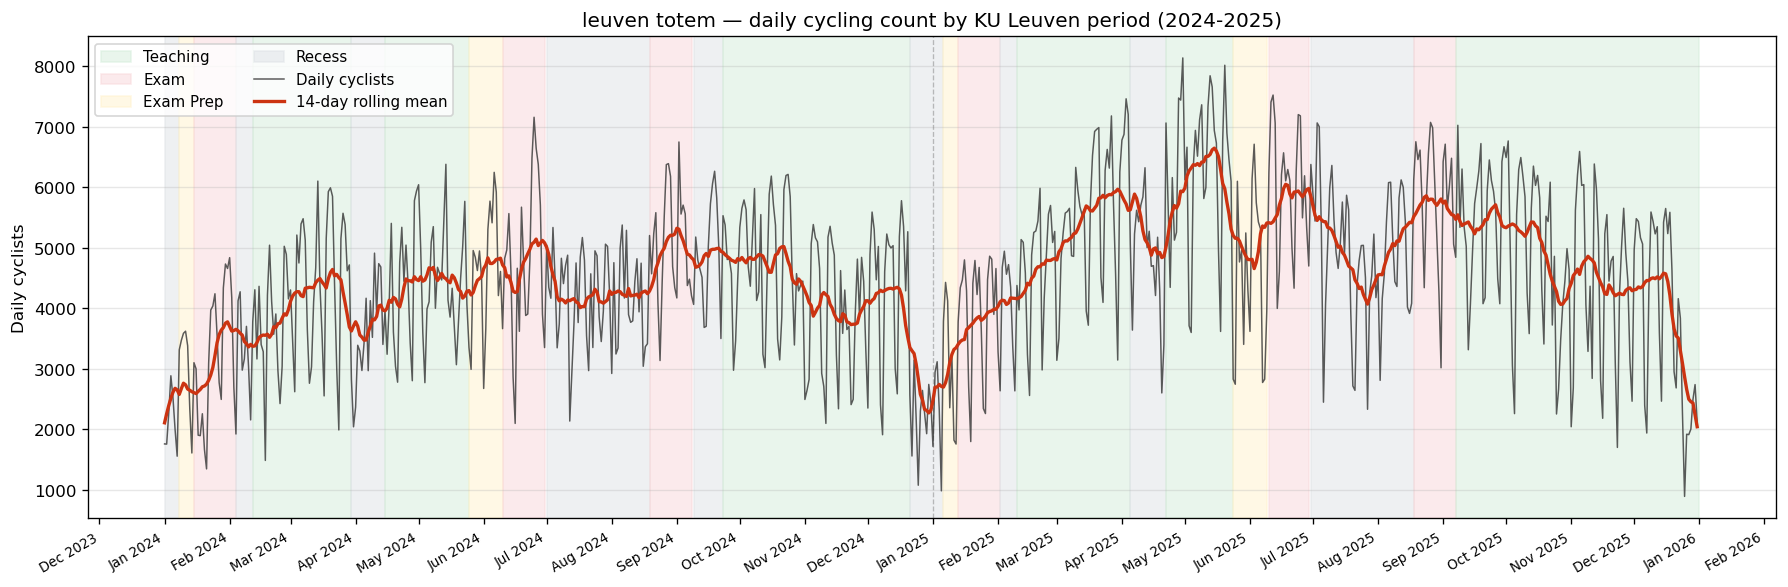

fig09_leuven_totem_kuleuven.png saved.


In [13]:
KU_COLORS = {
    "teaching":  "#d4edda",   # light green
    "exam":      "#f8d7da",   # light red
    "exam_prep": "#fff3cd",   # light yellow
    "recess":    "#dee2e6",   # light gray
}

# leuven totem (site ID 107): highest-volume, fully-covered Leuven station
# (gemeente Leuven, 731 days, 0% NaN, ~4 547 avg daily cyclists)
site_data = merged[merged["site ID"] == 107].sort_values("date").copy()

site_name = site_data["naam"].iloc[0]
print(f"Plotting: {site_name}  (site ID {site_data['site ID'].iloc[0]})")

# Build contiguous blocks of same KU Leuven period
ku_tl = (
    site_data[["date", "ku_leuven_period"]]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)
ku_tl["block"] = (
    ku_tl["ku_leuven_period"] != ku_tl["ku_leuven_period"].shift()
).cumsum()

fig, ax = plt.subplots(figsize=(15, 5))

legend_seen = set()
for _, blk in ku_tl.groupby("block"):
    period = blk["ku_leuven_period"].iloc[0]
    if pd.isna(period) or period not in KU_COLORS:
        continue
    ax.axvspan(
        blk["date"].iloc[0],
        blk["date"].iloc[-1] + pd.Timedelta("1D"),
        color=KU_COLORS[period], alpha=0.5, zorder=0,
    )
    legend_seen.add(period)

# Cycling count + rolling mean
ax.plot(site_data["date"], site_data["aantal"],
        color="#333", lw=0.9, alpha=0.8, zorder=3, label="Daily cyclists")
roll14 = site_data["aantal"].rolling(14, center=True, min_periods=7).mean()
ax.plot(site_data["date"], roll14,
        color="#cc3311", lw=2.0, zorder=4, label="14-day rolling mean")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right", fontsize=8)
ax.axvline(pd.Timestamp("2025-01-01"), color="grey", lw=0.8, ls="--", alpha=0.5)
ax.set_ylabel("Daily cyclists")
ax.set_title(f"{site_name} — daily cycling count by KU Leuven period (2024-2025)")
ax.grid(axis="y", alpha=0.3)

period_patches = [
    Patch(color=KU_COLORS[p], alpha=0.5, label=p.replace("_", " ").title())
    for p in ["teaching", "exam", "exam_prep", "recess"]
    if p in legend_seen
]
data_handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=period_patches + data_handles, fontsize=9, loc="upper left", ncol=2)

fig.tight_layout()
fig.savefig(FIGS / "fig09_leuven_totem_kuleuven.png", dpi=150)
plt.show()
print("fig09_leuven_totem_kuleuven.png saved.")

## 11. Final Summary

In [12]:
dates_uniq  = merged[["date", "day_type", "ku_leuven_period"]].drop_duplicates("date")
total_days  = len(dates_uniq)
dt_counts   = dates_uniq["day_type"].value_counts()
ku_counts   = dates_uniq["ku_leuven_period"].value_counts()

n_well  = merged[~merged["low_coverage"]]["site ID"].nunique()
n_low   = merged[ merged["low_coverage"]]["site ID"].nunique()
wx_cov  = merged["temp_avg"].notna().mean() * 100
sz_mb   = (PROCESSED / "analysis_panel.parquet").stat().st_size / 1_048_576

print("=" * 52)
print("FINAL ANALYSIS PANEL SUMMARY")
print("=" * 52)
print(f"Shape           : {merged.shape[0]:,} rows x {merged.shape[1]} columns")
print(f"Sites           : {merged['site ID'].nunique()} "
      f"(well-covered: {n_well}, low_coverage: {n_low})")
print(f"Date range      : {merged['date'].min().date()} -> {merged['date'].max().date()}")
print()
print("Day type breakdown:")
for dt in ["regular_weekday", "weekend", "school_holiday", "public_holiday"]:
    n = dt_counts.get(dt, 0)
    print(f"  {dt:<20} : {n:>4} days ({n / total_days * 100:.1f}%)")
print()
print("KU Leuven period breakdown (calendar days):")
for p in ["teaching", "exam", "exam_prep", "recess"]:
    n = ku_counts.get(p, 0)
    print(f"  {p:<12} : {n} days")
print()
print(f"Weather coverage : {wx_cov:.1f}% non-NaN in temp_avg")
print(f"Lag vars ready   : lag1 and lag2 for temp, precip, wind")
print()
print(f"Saved: data/processed/analysis_panel.parquet ({sz_mb:.1f} MB)")
print("=" * 52)

FINAL ANALYSIS PANEL SUMMARY
Shape           : 108,919 rows x 54 columns
Sites           : 149 (well-covered: 132, low_coverage: 17)
Date range      : 2024-01-01 -> 2025-12-31

Day type breakdown:
  regular_weekday      :  362 days (49.5%)
  weekend              :  202 days (27.6%)
  school_holiday       :  143 days (19.6%)
  public_holiday       :   24 days (3.3%)

KU Leuven period breakdown (calendar days):
  teaching     : 378 days
  exam         : 119 days
  exam_prep    : 46 days
  recess       : 184 days

Weather coverage : 100.0% non-NaN in temp_avg
Lag vars ready   : lag1 and lag2 for temp, precip, wind

Saved: data/processed/analysis_panel.parquet (4.8 MB)
